In [1]:
# Class Imbalance ----> Unbalanced dataset
# Handling Imbalanced data -----> Goal is to convert the given unbalanced dataset into a balanced dataset
#
#
# e.g.
# Spam -- 100
# Ham --- 91

# Goal: Convert the unbalanced dataset into balanced
#
# a. Delete 9 records from Spam
# b. Use SMOTE to generate synthetic data

# SMOTE ( Synthetic Minority OverSampling TechniquE )

In [2]:
import pandas as pd
import numpy as np

In [3]:
data = pd.read_csv("Social_Network_Ads.csv")

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [5]:
data.Purchased.value_counts()

,count
Purchased,
0,257
1,143


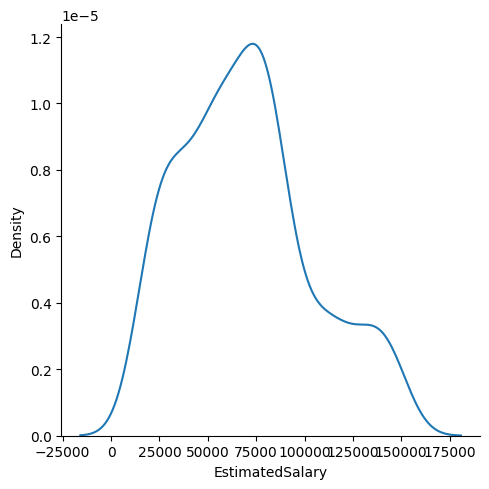

In [15]:
import seaborn as sns
sns.displot(data.EstimatedSalary, kind="kde")

<Axes: ylabel='EstimatedSalary'>

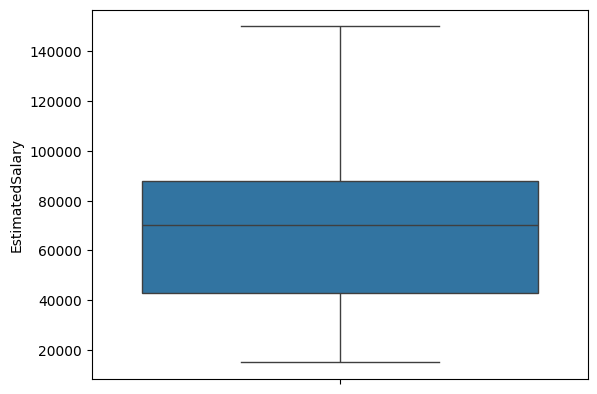

In [16]:
sns.boxplot(data.EstimatedSalary)

In [17]:
data.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [ ]:
#pip install imbalanced-learn

In [6]:
from imblearn.over_sampling import SMOTE

In [7]:
features = data.iloc[:,[0,1]]
label = data.iloc[:,[2]]

In [8]:
smoteObject = SMOTE(random_state=1)

In [9]:
transformedFeatures, transformedLabels = smoteObject.fit_resample(features,label)

In [12]:
revisedDataset = pd.concat([pd.DataFrame(transformedFeatures, columns=features.columns), pd.DataFrame(transformedLabels, columns=label.columns)], axis = 1)

In [13]:
revisedDataset.Purchased.value_counts()
#

,count
Purchased,
0,257
1,257


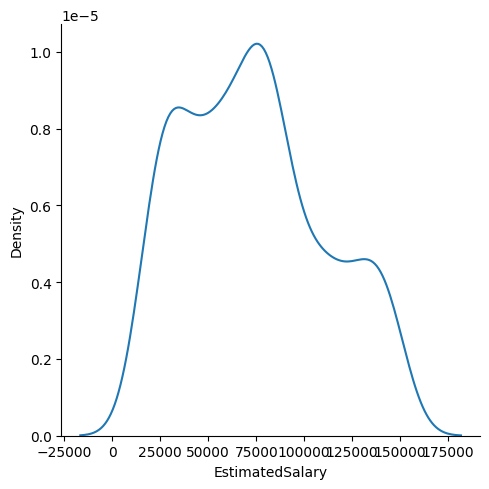

In [18]:
sns.displot(revisedDataset.EstimatedSalary, kind='kde')

<Axes: ylabel='EstimatedSalary'>

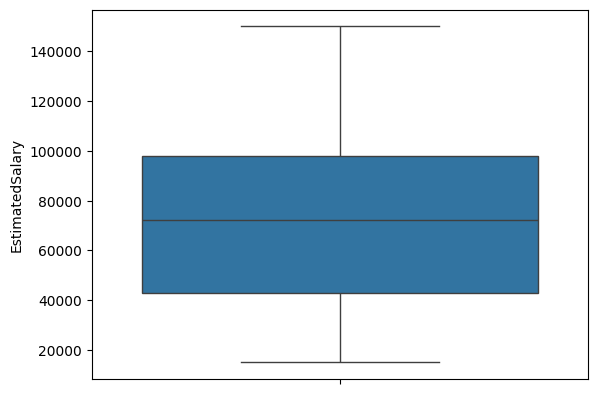

In [19]:
sns.boxplot(revisedDataset.EstimatedSalary)

In [20]:
revisedDataset.describe()

,Age,EstimatedSalary,Purchased
count,514.000000,514.000000,514.000000
mean,39.587549,73694.978599,0.500000
std,10.570340,36835.526352,0.500487
min,18.000000,15000.000000,0.000000
25%,32.000000,43000.000000,0.000000
50%,39.000000,72000.000000,0.500000
75%,48.000000,97975.500000,1.000000
max,60.000000,150000.000000,1.000000
